**Importing Necessary Libraries**

In [1]:
import pandas as pd
import numpy as np
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, LinearSVC
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import  accuracy_score,precision_score, recall_score, f1_score, classification_report

**Data Collection and Preprocessing**

In [2]:
#Loading the dataset to pandas DataFrame
toddlers_df = pd.read_csv("ASD Dataset.csv")
type(toddlers_df)

pandas.core.frame.DataFrame

In [3]:
#Printing the first 5 rows of the dataframe
toddlers_df.head()

,Case_No,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Age_Mons,Qchat-10-Score,Sex,Ethnicity,Jaundice,Family_mem_with_ASD,Who completed the test,class
0,1,0,0,0,0,0,0,1,1,0,1,28,3,f,middle eastern,yes,no,family member,No
1,2,1,1,0,0,0,1,1,0,0,0,36,4,m,White European,yes,no,family member,Yes
2,3,1,0,0,0,0,0,1,1,0,1,36,4,m,middle eastern,yes,no,family member,Yes
3,4,1,1,1,1,1,1,1,1,1,1,24,10,m,Hispanic,no,no,family member,Yes
4,5,1,1,0,1,1,1,1,1,1,1,20,9,f,White European,no,yes,family member,Yes


In [4]:
toddlers_df.columns

Index(['Case_No', 'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10',
       'Age_Mons', 'Qchat-10-Score', 'Sex', 'Ethnicity', 'Jaundice',
       'Family_mem_with_ASD', 'Who completed the test', 'class'],
      dtype='object')

In [5]:
toddlers_df['Who completed the test'].unique()

array(['family member', 'Health Care Professional',
       'Health care professional', 'Self', 'Others'], dtype=object)

In [6]:
toddlers_df['Ethnicity'].unique()

array(['middle eastern', 'White European', 'Hispanic', 'black', 'asian',
       'south asian', 'Native Indian', 'Others', 'Latino', 'mixed',
       'Pacifica'], dtype=object)

In [7]:
toddlers_df = toddlers_df.replace('Health care professional', 'Health Care Professional')
toddlers_df = toddlers_df.replace('middle eastern', 'Middle Eastern')
toddlers_df = toddlers_df.replace('asian', 'Asian')
toddlers_df = toddlers_df.replace('black', 'Black')
toddlers_df = toddlers_df.replace('south asian', 'South Asian')
toddlers_df = toddlers_df.replace('mixed', 'Mixed')

In [8]:
toddlers_df.iloc[22]

Case_No                                         23
A1                                               1
A2                                               0
A3                                               1
A4                                               1
A5                                               0
A6                                               1
A7                                               0
A8                                               1
A9                                               1
A10                                              1
Age_Mons                                        36
Qchat-10-Score                                   7
Sex                                              m
Ethnicity                            Native Indian
Jaundice                                       yes
Family_mem_with_ASD                            yes
Who completed the test    Health Care Professional
class                                          Yes
Name: 22, dtype: object

In [9]:
toddlers_df.isnull().sum()

Case_No                   0
A1                        0
A2                        0
A3                        0
A4                        0
A5                        0
A6                        0
A7                        0
A8                        0
A9                        0
A10                       0
Age_Mons                  0
Qchat-10-Score            0
Sex                       0
Ethnicity                 0
Jaundice                  0
Family_mem_with_ASD       0
Who completed the test    0
class                     0
dtype: int64

In [10]:
#convert categorical columns into numerical values
toddlers_df = toddlers_df.replace("yes", 1)
toddlers_df = toddlers_df.replace("no", 0)
toddlers_df = toddlers_df.replace("Yes", 1)
toddlers_df = toddlers_df.replace("No", 0)
toddlers_df = toddlers_df.replace("m", 1)
toddlers_df = toddlers_df.replace("f", 0)

C:\Users\HP\AppData\Local\Temp\ipykernel_23952\2585627195.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  toddlers_df = toddlers_df.replace("no", 0)
C:\Users\HP\AppData\Local\Temp\ipykernel_23952\2585627195.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  toddlers_df = toddlers_df.replace("No", 0)
C:\Users\HP\AppData\Local\Temp\ipykernel_23952\2585627195.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_obje

In [11]:
toddlers_df = toddlers_df.rename(columns={'class':'ASD traits'})

In [12]:
toddlers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1054 entries, 0 to 1053
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Case_No                 1054 non-null   int64 
 1   A1                      1054 non-null   int64 
 2   A2                      1054 non-null   int64 
 3   A3                      1054 non-null   int64 
 4   A4                      1054 non-null   int64 
 5   A5                      1054 non-null   int64 
 6   A6                      1054 non-null   int64 
 7   A7                      1054 non-null   int64 
 8   A8                      1054 non-null   int64 
 9   A9                      1054 non-null   int64 
 10  A10                     1054 non-null   int64 
 11  Age_Mons                1054 non-null   int64 
 12  Qchat-10-Score          1054 non-null   int64 
 13  Sex                     1054 non-null   int64 
 14  Ethnicity               1054 non-null   object
 15  Jaun

In [13]:
toddlers_df.shape

(1054, 19)

In [14]:
toddlers_df.head()

,Case_No,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Age_Mons,Qchat-10-Score,Sex,Ethnicity,Jaundice,Family_mem_with_ASD,Who completed the test,ASD traits
0,1,0,0,0,0,0,0,1,1,0,1,28,3,0,Middle Eastern,1,0,family member,0
1,2,1,1,0,0,0,1,1,0,0,0,36,4,1,White European,1,0,family member,1
2,3,1,0,0,0,0,0,1,1,0,1,36,4,1,Middle Eastern,1,0,family member,1
3,4,1,1,1,1,1,1,1,1,1,1,24,10,1,Hispanic,0,0,family member,1
4,5,1,1,0,1,1,1,1,1,1,1,20,9,0,White European,0,1,family member,1


In [15]:
toddlers_df.drop(['Case_No','Qchat-10-Score'], axis=1, inplace=True)

In [16]:
toddlers_df = toddlers_df.replace("Middle Eastern",0)
toddlers_df = toddlers_df.replace("White European",1)
toddlers_df = toddlers_df.replace('Hispanic',2)
toddlers_df = toddlers_df.replace('Others',3)
toddlers_df = toddlers_df.replace('Asian',4)
toddlers_df = toddlers_df.replace('South Asian',5)
toddlers_df = toddlers_df.replace('Native Indian',6)
toddlers_df = toddlers_df.replace('Black',7)
toddlers_df = toddlers_df.replace('Latino',8)
toddlers_df = toddlers_df.replace('Mixed',9)
toddlers_df = toddlers_df.replace('Pacifica',10)

C:\Users\HP\AppData\Local\Temp\ipykernel_23952\213783849.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  toddlers_df = toddlers_df.replace('Pacifica',10)


In [17]:
toddlers_df = toddlers_df.replace('family member',0)
toddlers_df = toddlers_df.replace('Health Care Professional',1)
toddlers_df = toddlers_df.replace('Self',2)

C:\Users\HP\AppData\Local\Temp\ipykernel_23952\3769762744.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  toddlers_df = toddlers_df.replace('Self',2)


In [18]:
toddlers_df.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Age_Mons,Sex,Ethnicity,Jaundice,Family_mem_with_ASD,Who completed the test,ASD traits
0,0,0,0,0,0,0,1,1,0,1,28,0,0,1,0,0,0
1,1,1,0,0,0,1,1,0,0,0,36,1,1,1,0,0,1
2,1,0,0,0,0,0,1,1,0,1,36,1,0,1,0,0,1
3,1,1,1,1,1,1,1,1,1,1,24,1,2,0,0,0,1
4,1,1,0,1,1,1,1,1,1,1,20,0,1,0,1,0,1


In [19]:
toddlers_df.shape

(1054, 17)

In [20]:
toddlers_df.columns

Index(['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'Age_Mons',
       'Sex', 'Ethnicity', 'Jaundice', 'Family_mem_with_ASD',
       'Who completed the test', 'ASD traits'],
      dtype='object')

In [21]:
col=['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'Age_Mons','Sex', 'Ethnicity', 'Jaundice', 'Family_mem_with_ASD','Who completed the test', 'ASD traits']

In [22]:
for i in col:
    print(i)
    print(toddlers_df[i].value_counts())
    print(" ")

A1
A1
1    594
0    460
Name: count, dtype: int64
 
A2
A2
0    581
1    473
Name: count, dtype: int64
 
A3
A3
0    631
1    423
Name: count, dtype: int64
 
A4
A4
1    540
0    514
Name: count, dtype: int64
 
A5
A5
1    553
0    501
Name: count, dtype: int64
 
A6
A6
1    608
0    446
Name: count, dtype: int64
 
A7
A7
1    685
0    369
Name: count, dtype: int64
 
A8
A8
0    570
1    484
Name: count, dtype: int64
 
A9
A9
0    538
1    516
Name: count, dtype: int64
 
A10
A10
1    618
0    436
Name: count, dtype: int64
 
Age_Mons
Age_Mons
36    320
24     70
12     67
30     67
28     42
33     36
26     36
34     34
15     31
32     30
31     30
35     30
23     28
22     27
25     26
29     24
27     23
20     21
19     21
14     19
13     18
18     16
21     13
16     13
17     12
Name: count, dtype: int64
 
Sex
Sex
1    735
0    319
Name: count, dtype: int64
 
Ethnicity
Ethnicity
1     334
4     299
0     188
5      60
7      53
2      40
3      35
8      26
9       8
10      8
6       

<Axes: >

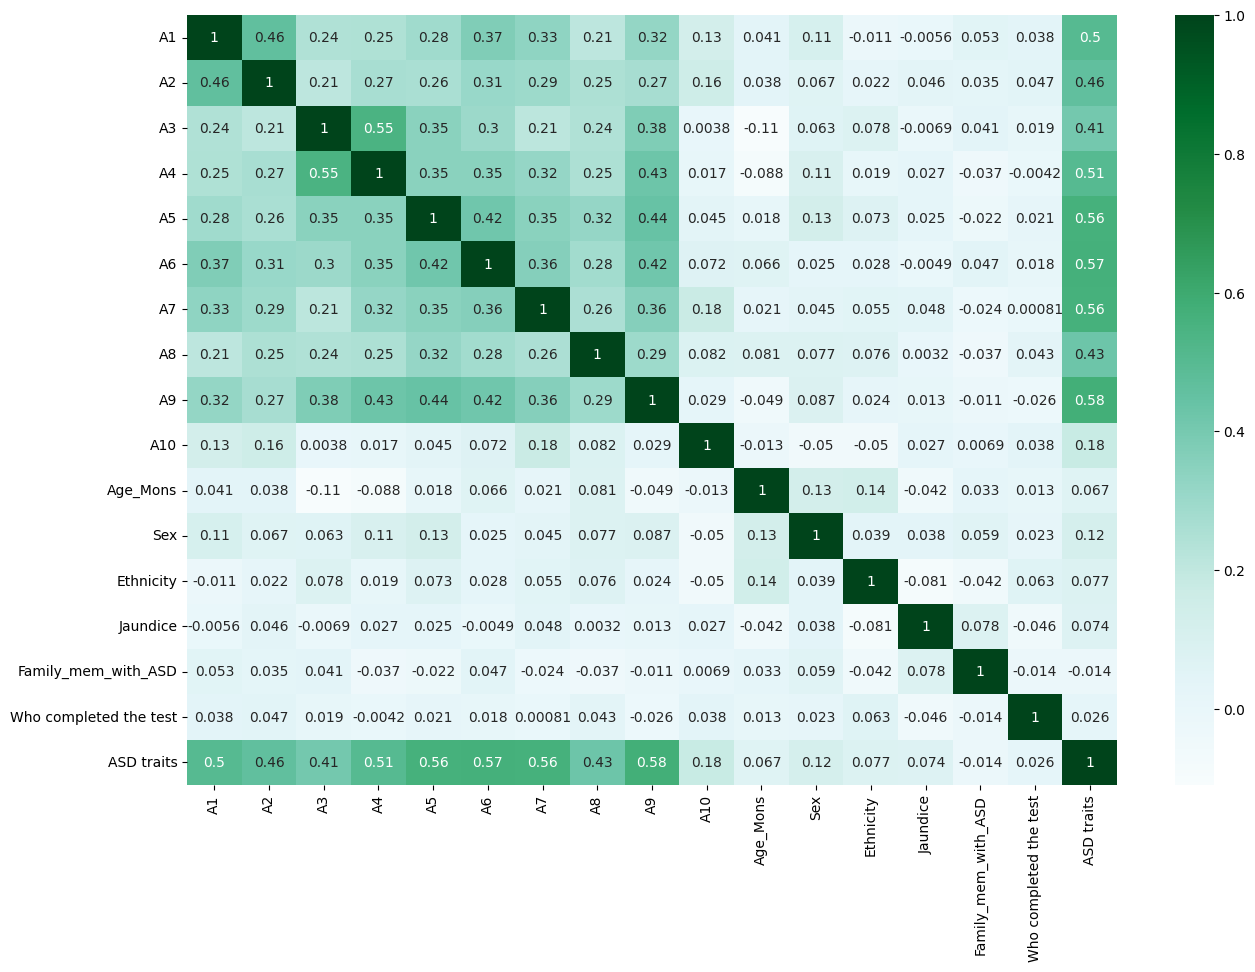

In [23]:
# import visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
corr_toddlers = toddlers_df.corr()

plt.figure(figsize = (15, 10))
# plt.title("Toddler Dataset Features Correlations Heatmap", fontsize = 14)
sns.heatmap(corr_toddlers, annot = True, cmap = "BuGn")

In [24]:
y = toddlers_df['ASD traits']
x = toddlers_df.drop(['ASD traits'], axis=1)


**Data Standardization**

In [ ]:
scaler = StandardScaler()        # Create scaler object
scaler.fit(x.values)             # Compute mean and std of dataset
StandardScaler()                 # Display scaler object

standardizedata = scaler.transform(x.values)  # Standardize the data

print(standardizedata)           # Print scaled data

[[-1.13635573 -0.90228244 -0.8187579  ...  1.63086548 -0.43852901
  -0.16936047]
 [ 0.88000612  1.10830041 -0.8187579  ...  1.63086548 -0.43852901
  -0.16936047]
 [ 0.88000612 -0.90228244 -0.8187579  ...  1.63086548 -0.43852901
  -0.16936047]
 ...
 [ 0.88000612 -0.90228244  1.22136226 ...  1.63086548 -0.43852901
  -0.16936047]
 [ 0.88000612 -0.90228244 -0.8187579  ... -0.61317136  2.28035085
  -0.16936047]
 [ 0.88000612  1.10830041 -0.8187579  ...  1.63086548  2.28035085
  -0.16936047]]


In [26]:
import pickle

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)


In [27]:
# drop target feature 'ASD traits'
y = toddlers_df['ASD traits']
X = toddlers_df.drop(['ASD traits'], axis=1)

**Train Test Split**

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=True)

In [29]:
print(X.shape,X_train.shape,X_test.shape)

(1054, 16) (843, 16) (211, 16)


In [30]:
# Creating holders to store the model performance results
ML_Model = []
acc_train = []
acc_test = []

#function to call for storing the results
def storeResults(model, a,b):
  ML_Model.append(model)
  acc_train.append(round(a, 3))
  acc_test.append(round(b, 3))

**Training the model**

**Support Vector Machine Model**

In [31]:
sv=svm.SVC()
sv.fit( X_train.values,y_train)
xtrain_prediction=sv.predict(X_train.values)
train_data_accuracy=accuracy_score(xtrain_prediction,y_train)

In [32]:
#SVM Model
x_test_prediction=sv.predict(X_test.values)
test_data_accuracy=accuracy_score(x_test_prediction,y_test)
print('Accuracy for Test Data: ',test_data_accuracy)

Accuracy for Test Data:  0.8720379146919431


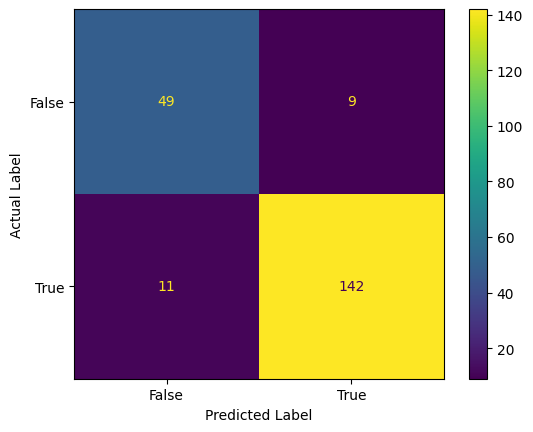

In [75]:
from sklearn import metrics
confusion_matrix = metrics.confusion_matrix(y_test,x_test_prediction)

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [False, True])

cm_display.plot()
plt.ylabel("Actual Label")     # Y-axis label
plt.xlabel("Predicted Label")  # X-axis label
plt.show()

In [34]:
precision = precision_score(y_test, x_test_prediction)
recall = recall_score(y_test, x_test_prediction)
f1 = f1_score(y_test, x_test_prediction)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

# --- Or get them all together ---
print("\nClassification Report:\n")
print(classification_report(y_test, x_test_prediction))

Precision: 0.8579545454545454
Recall: 0.9869281045751634
F1 Score: 0.9179331306990881

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.57      0.71        58
           1       0.86      0.99      0.92       153

    accuracy                           0.87       211
   macro avg       0.90      0.78      0.81       211
weighted avg       0.88      0.87      0.86       211



In [35]:
#storing the results. The below mentioned order of parameter passing is important.
#Caution: Execute only once to avoid duplications.
storeResults('SVM', train_data_accuracy, test_data_accuracy)

Logistic Regression


In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

log_reg = LogisticRegression(max_iter=1000)   # ensure convergence
log_reg.fit(X_train.values, y_train)

xtrain_prediction = log_reg.predict(X_train.values)
train_data_accuracy = accuracy_score(y_train, xtrain_prediction)
train_data_accuracy


1.0

In [37]:
x_test_prediction = log_reg.predict(X_test.values)
test_data_accuracy = accuracy_score(y_test, x_test_prediction)
print('Accuracy for Test Data: ', test_data_accuracy)


Accuracy for Test Data:  1.0


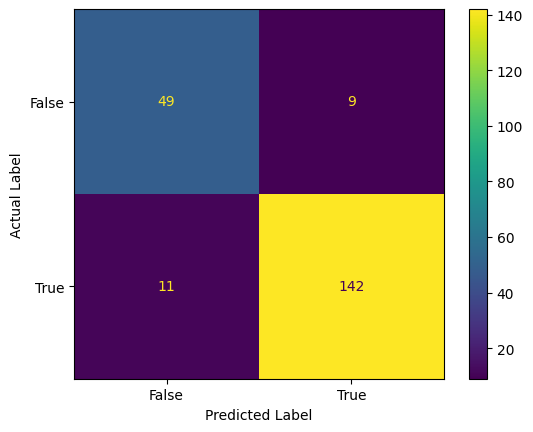

In [76]:
from sklearn import metrics
import matplotlib.pyplot as plt

confusion_matrix = metrics.confusion_matrix(y_test, x_test_prediction)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=confusion_matrix,
                                            display_labels=[False, True])

cm_display.plot()
plt.ylabel("Actual Label")     # Y-axis label
plt.xlabel("Predicted Label")  # X-axis label
plt.show()

In [39]:
precision = precision_score(y_test, x_test_prediction)
recall = recall_score(y_test, x_test_prediction)
f1 = f1_score(y_test, x_test_prediction)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

# --- Detailed Report ---
print("\nClassification Report:\n")
print(classification_report(y_test, x_test_prediction))

Precision: 1.0
Recall: 1.0
F1 Score: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        58
           1       1.00      1.00      1.00       153

    accuracy                           1.00       211
   macro avg       1.00      1.00      1.00       211
weighted avg       1.00      1.00      1.00       211



In [40]:
storeResults('Logistic Regression', train_data_accuracy, test_data_accuracy)


**Random Forest Classifier**

In [41]:
rf = rf = RandomForestClassifier(class_weight='balanced', max_depth=3, max_features=0.1,n_estimators=50,random_state=11)
rf = rf.fit(X_train.values,y_train)
xtrain_prediction=rf.predict(X_train.values)
train_data_accu=accuracy_score(xtrain_prediction,y_train)

In [42]:
#Random Forest Model
x_test_prediction=rf.predict(X_test.values)
test_data_accu=accuracy_score(x_test_prediction,y_test)
print('Accuracy for Test Data: ',test_data_accu)

Accuracy for Test Data:  0.9383886255924171


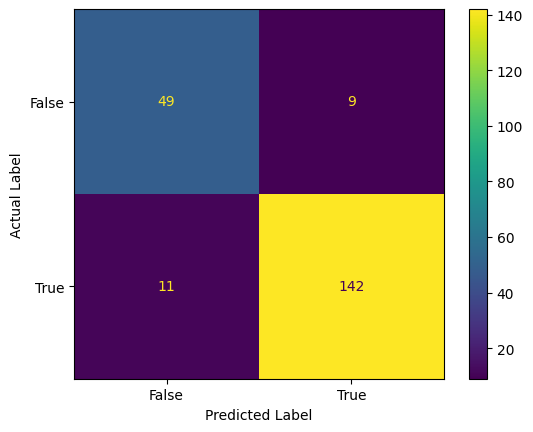

In [77]:
from sklearn import metrics
confusion_matrix = metrics.confusion_matrix(y_test,x_test_prediction)

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [False, True])

cm_display.plot()
plt.ylabel("Actual Label")     # Y-axis label
plt.xlabel("Predicted Label")  # X-axis label
plt.show()

In [44]:
precision = precision_score(y_test, x_test_prediction)
recall = recall_score(y_test, x_test_prediction)
f1 = f1_score(y_test, x_test_prediction)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

# --- Detailed Report ---
print("\nClassification Report:\n")
print(classification_report(y_test, x_test_prediction))

Precision: 1.0
Recall: 0.9150326797385621
F1 Score: 0.9556313993174061

Classification Report:

              precision    recall  f1-score   support

           0       0.82      1.00      0.90        58
           1       1.00      0.92      0.96       153

    accuracy                           0.94       211
   macro avg       0.91      0.96      0.93       211
weighted avg       0.95      0.94      0.94       211



In [45]:
#storing the results. The below mentioned order of parameter passing is important.
#Caution: Execute only once to avoid duplications.
storeResults('Random Forest', train_data_accu, test_data_accu)

Naive Bayes

In [46]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

nb = GaussianNB()
nb.fit(X_train.values, y_train)

xtrain_prediction = nb.predict(X_train.values)
train_data_accuracy = accuracy_score(y_train, xtrain_prediction)
train_data_accuracy


0.9430604982206405

In [47]:
x_test_prediction = nb.predict(X_test.values)
test_data_accuracy = accuracy_score(y_test, x_test_prediction)
print('Accuracy for Test Data: ', test_data_accuracy)


Accuracy for Test Data:  0.95260663507109


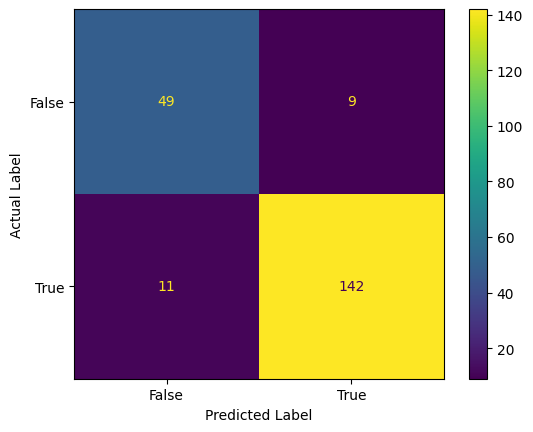

In [78]:
from sklearn import metrics
import matplotlib.pyplot as plt

confusion_matrix = metrics.confusion_matrix(y_test, x_test_prediction)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=confusion_matrix,
                                            display_labels=[False, True])

cm_display.plot()
plt.ylabel("Actual Label")     # Y-axis label
plt.xlabel("Predicted Label")  # X-axis label
plt.show()


In [49]:
precision = precision_score(y_test, x_test_prediction)
recall = recall_score(y_test, x_test_prediction)
f1 = f1_score(y_test, x_test_prediction)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

# --- Detailed Report ---
print("\nClassification Report:\n")
print(classification_report(y_test, x_test_prediction))

Precision: 0.9863945578231292
Recall: 0.9477124183006536
F1 Score: 0.9666666666666667

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.97      0.92        58
           1       0.99      0.95      0.97       153

    accuracy                           0.95       211
   macro avg       0.93      0.96      0.94       211
weighted avg       0.96      0.95      0.95       211



In [50]:
storeResults('Naive Bayes', train_data_accuracy, test_data_accuracy)

Decision Tree

In [51]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Initialize and train Decision Tree
dt = DecisionTreeClassifier(random_state=42)  # you can adjust max_depth, criterion etc.
dt.fit(X_train.values, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [52]:
# Training data prediction
xtrain_prediction = dt.predict(X_train.values)
train_data_accuracy = accuracy_score(xtrain_prediction, y_train)

# Test data prediction
x_test_prediction = dt.predict(X_test.values)
test_data_accuracy = accuracy_score(x_test_prediction, y_test)

print('Accuracy for Test Data: ', test_data_accuracy)


Accuracy for Test Data:  0.8672985781990521


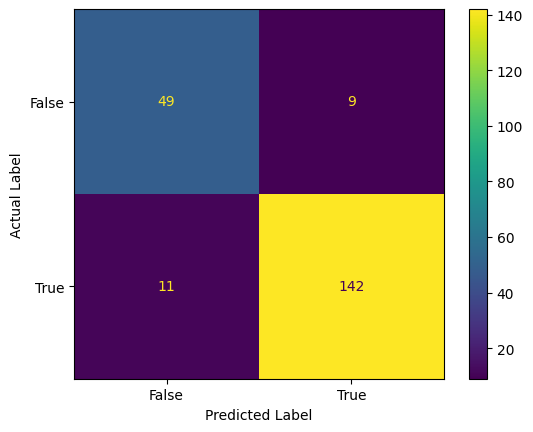

In [79]:
# Confusion Matrix
confusion_matrix = metrics.confusion_matrix(y_test, x_test_prediction)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=confusion_matrix, display_labels=[False, True])
cm_display.plot()
plt.ylabel("Actual Label")     # Y-axis label
plt.xlabel("Predicted Label")  # X-axis label
plt.show()

# Store results (execute only once)
storeResults('Decision Tree', train_data_accuracy, test_data_accuracy)


In [54]:
precision = precision_score(y_test, x_test_prediction)
recall = recall_score(y_test, x_test_prediction)
f1 = f1_score(y_test, x_test_prediction)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

# --- Detailed Report ---
print("\nClassification Report:\n")
print(classification_report(y_test, x_test_prediction))

Precision: 0.9370629370629371
Recall: 0.8758169934640523
F1 Score: 0.9054054054054054

Classification Report:

              precision    recall  f1-score   support

           0       0.72      0.84      0.78        58
           1       0.94      0.88      0.91       153

    accuracy                           0.87       211
   macro avg       0.83      0.86      0.84       211
weighted avg       0.88      0.87      0.87       211



KNN

In [55]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Initialize and train KNN
knn = KNeighborsClassifier(n_neighbors=5)  # You can change n_neighbors as needed
knn.fit(X_train.values, y_train)


,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [56]:
# Training data prediction
xtrain_prediction = knn.predict(X_train.values)
train_data_accuracy = accuracy_score(xtrain_prediction, y_train)

# Test data prediction
x_test_prediction = knn.predict(X_test.values)
test_data_accuracy = accuracy_score(x_test_prediction, y_test)

print('Accuracy for Test Data: ', test_data_accuracy)


Accuracy for Test Data:  0.9052132701421801


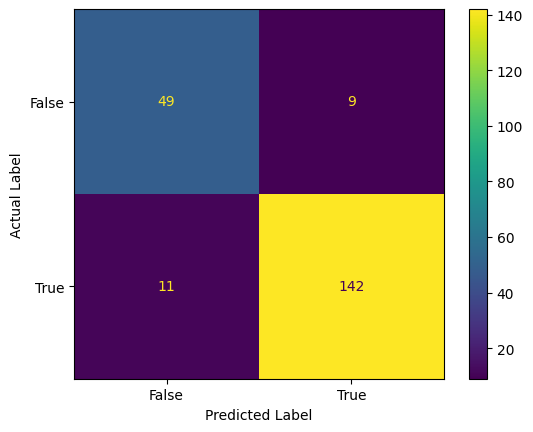

In [80]:
# Confusion Matrix
confusion_matrix = metrics.confusion_matrix(y_test, x_test_prediction)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=confusion_matrix, display_labels=[False, True])
cm_display.plot()
plt.ylabel("Actual Label")     # Y-axis label
plt.xlabel("Predicted Label")  # X-axis label
plt.show()

# Store results (execute only once)
storeResults('KNN', train_data_accuracy, test_data_accuracy)


In [58]:
precision = precision_score(y_test, x_test_prediction)
recall = recall_score(y_test, x_test_prediction)
f1 = f1_score(y_test, x_test_prediction)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

# --- Detailed Report ---
print("\nClassification Report:\n")
print(classification_report(y_test, x_test_prediction))

Precision: 0.9403973509933775
Recall: 0.9281045751633987
F1 Score: 0.9342105263157895

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.84      0.83        58
           1       0.94      0.93      0.93       153

    accuracy                           0.91       211
   macro avg       0.88      0.89      0.88       211
weighted avg       0.91      0.91      0.91       211



In [59]:
#creating dataframe
results = pd.DataFrame({ 'ML Model': ML_Model,    
                         'Train Accuracy': acc_train,
                        'Test Accuracy': acc_test})
results

,ML Model,Train Accuracy,Test Accuracy
0,SVM,0.865,0.872
1,Logistic Regression,1.000,1.000
2,Random Forest,0.948,0.938
3,Naive Bayes,0.943,0.953
4,Decision Tree,1.000,0.867
5,KNN,0.955,0.905


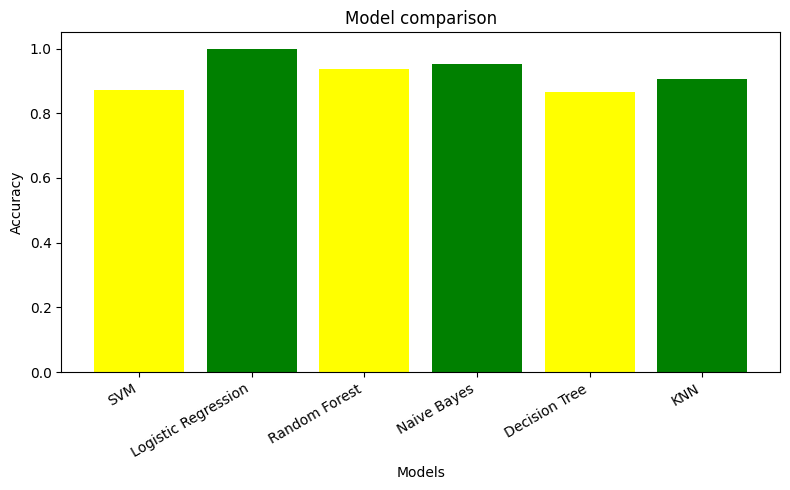

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib import style

# Example
r = results['ML Model']
s = results['Test Accuracy']
colo = ["yellow", "green"]

plt.figure(figsize=(8, 5))  # Increase figure size
plt.bar(r, s, color=colo)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model comparison")
plt.xticks(rotation=30, ha='right')  # Rotate x labels to avoid overlap
plt.tight_layout()  # Adjust spacing automatically
plt.show()


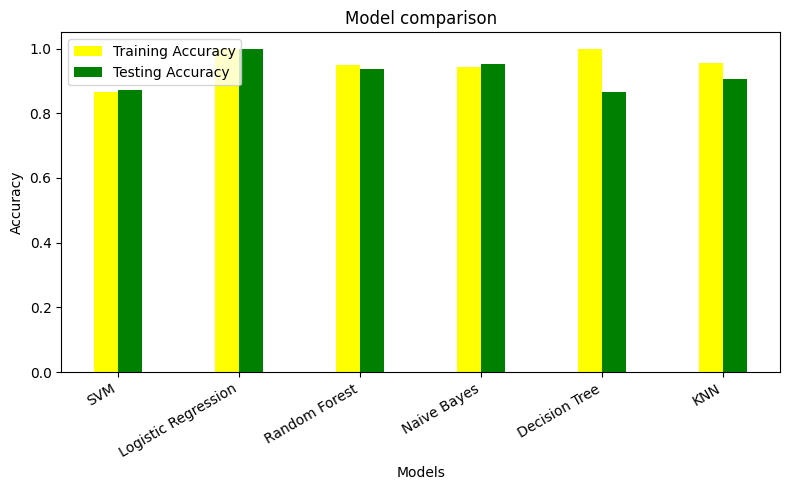

In [61]:
import numpy as np
import matplotlib.pyplot as plt

fb = results["Train Accuracy"]
yt = results["Test Accuracy"]
xp = results["ML Model"]

bandwidth = 0.2
xpls = np.arange(len(fb))

plt.figure(figsize=(8, 5))  # increase figure size

# Bars side by side
plt.bar(xpls - bandwidth/2, fb, color="yellow", width=bandwidth, label="Training Accuracy")
plt.bar(xpls + bandwidth/2, yt, color="green", width=bandwidth, label="Testing Accuracy")

# Labels and title
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model comparison")
plt.xticks(xpls, xp, rotation=30, ha='right')  # set tick positions and rotate labels
plt.legend()
plt.tight_layout()
plt.show()


C:\Users\HP\AppData\Local\Temp\ipykernel_23952\3420708174.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y=feat_importance.index, data=feat_importance, palette='BuGn_r')


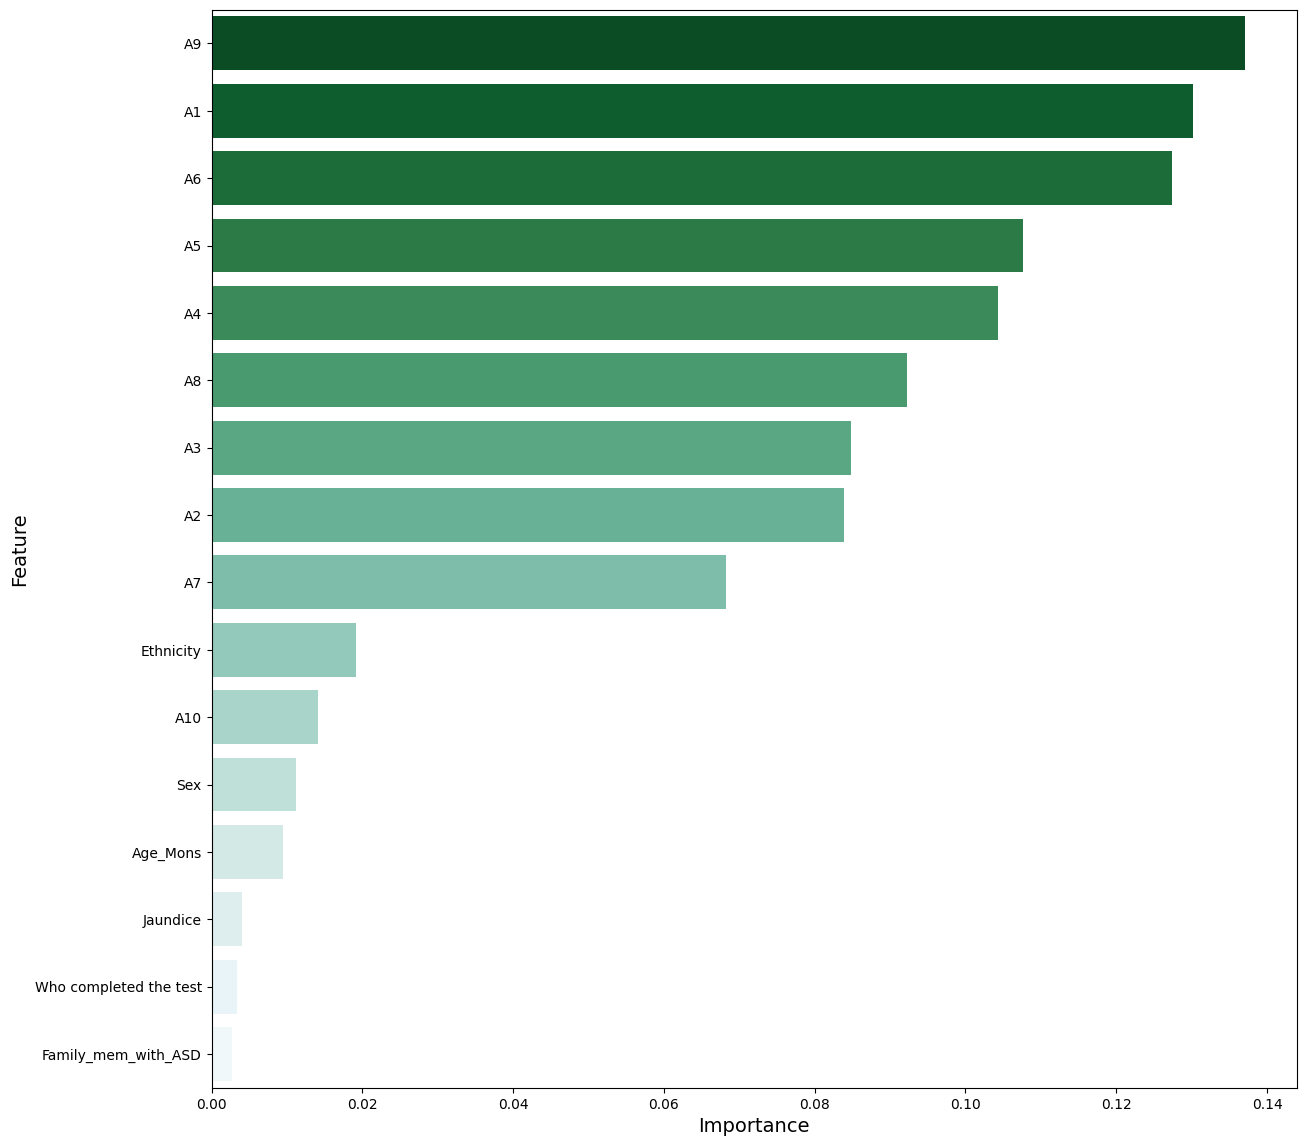

In [62]:
feat_importance = pd.DataFrame({'Feature':X_train.columns, 'Importance':rf.feature_importances_})
feat_importance = feat_importance.sort_values(by='Importance', ascending=False)
feat_importance = feat_importance.set_index('Feature')
plt.figure(figsize=(14,14))
sns.barplot(x='Importance', y=feat_importance.index, data=feat_importance, palette='BuGn_r')
# plt.title('Feature vs Importance')
plt.xlabel('Importance', fontsize=14)
plt.ylabel('Feature', fontsize=14)
plt.show()

**Making a Predictive Model**

In [63]:
from sklearn.linear_model import LogisticRegression
import joblib

# Train Logistic Regression
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train.values, y_train)

# Save the model to a file
joblib.dump(log_reg, "logistic_regression_model.sav")
print("✅ Logistic Regression model saved as logistic_regression_model.sav")


✅ Logistic Regression model saved as logistic_regression_model.sav


In [64]:
from sklearn import svm
import joblib

# Train SVM
sv = svm.SVC()
sv.fit(X_train.values, y_train)

# Save the model
joblib.dump(sv, "svm_model.sav")
print("✅ SVM model saved as svm_model.sav")


✅ SVM model saved as svm_model.sav


In [65]:
from sklearn.tree import DecisionTreeClassifier
import joblib

# Train Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train.values, y_train)

# Save the model
joblib.dump(dt, "decision_tree_model.sav")
print("✅ Decision Tree model saved as decision_tree_model.sav")


✅ Decision Tree model saved as decision_tree_model.sav


In [66]:
from sklearn.neighbors import KNeighborsClassifier
import joblib

# Train KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train.values, y_train)

# Save the model
joblib.dump(knn, "knn_model.sav")
print("✅ KNN model saved as knn_model.sav")


✅ KNN model saved as knn_model.sav


In [67]:
from sklearn.ensemble import RandomForestClassifier
import joblib

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train.values, y_train)

# Save the model
joblib.dump(rf, "random_forest_model.sav")
print("✅ Random Forest model saved as random_forest_model.sav")


✅ Random Forest model saved as random_forest_model.sav


In [68]:
input_data=(1,1,1,1,0,1,0,1,1,1,36,1,6,1,1,1)
input_data_as_numpy_array=np.asarray(input_data)
input_data_reshaped=input_data_as_numpy_array.reshape(1,-1)
prediction=rf.predict(input_data_reshaped)
print(prediction)
if prediction==0:
    print('Patient is non ASD')
else:
    print('Patient is ASD')

[1]
Patient is ASD


In [69]:
# 0=No 1=Yes
'''
1,0,0,0,0,0,1,1,0,1,28,0,0,1,0,0     0
0,0,0,0,0,0,1,1,0,1,28,0,0,1,0,0     0
1,1,0,0,0,1,1,0,0,0,36,1,1,1,0,0	 1
1,1,0,1,1,1,1,1,1,1,20,0,1,0,1,0	 1
1,1,0,0,1,1,1,1,1,1,21,1,7,0,0,0	 1
1,0,1,1,0,1,0,1,1,1,36,1,6,1,1,1	 1
'''

'\n1,0,0,0,0,0,1,1,0,1,28,0,0,1,0,0     0\n0,0,0,0,0,0,1,1,0,1,28,0,0,1,0,0     0\n1,1,0,0,0,1,1,0,0,0,36,1,1,1,0,0\t 1\n1,1,0,1,1,1,1,1,1,1,20,0,1,0,1,0\t 1\n1,1,0,0,1,1,1,1,1,1,21,1,7,0,0,0\t 1\n1,0,1,1,0,1,0,1,1,1,36,1,6,1,1,1\t 1\n'

In [70]:
import joblib
loader_model=joblib.load(open('logistic_regression_model.sav','rb'))

In [71]:
input_data=(1,0,0,0,0,0,1,1,0,1,28,0,0,1,0,0)
input_data_as_numpy_array=np.asarray(input_data)
input_data_reshaped=input_data_as_numpy_array.reshape(1,-1)
std_data=scaler.transform(input_data_reshaped)
#print(std_data)
prediction=loader_model.predict(std_data)
print(prediction)
if prediction==0:
    print('Patient is non ASD')
else:
    print('Patient is ASD')

[0]
Patient is non ASD


Prediction: [1]
Patient is ASD


C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


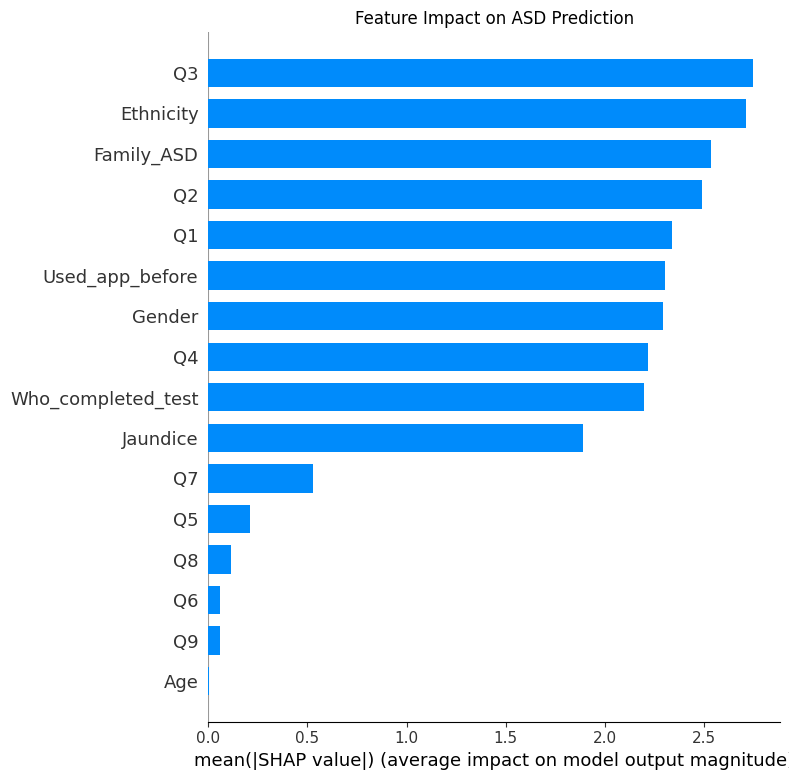

In [72]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Input
input_data = (1, 0,1, 1,0, 1, 0, 1, 1, 1, 36, 1, 4,1, 1, 1)
input_data_as_numpy_array = np.asarray(input_data)
input_data_reshaped = input_data_as_numpy_array.reshape(1, -1)

# Step 2: Standardize input
std_data = scaler.transform(input_data_reshaped)

# Step 3: Prediction
prediction = loader_model.predict(std_data)
print("Prediction:", prediction)

if prediction == 0:
    print('Patient is non ASD')
else:
    print('Patient is ASD')

# Step 4: Define feature names
feature_names = [
    'Gender', 'Ethnicity', 'Jaundice', 'Family_ASD', 'Used_app_before', 
    'Who_completed_test', 'Q1', 'Q2', 'Q3', 'Q4', 'Age', 
    'Q5', 'Q6', 'Q7', 'Q8', 'Q9', 'Q10'
]

# Step 5: Background data (use real training data if available)
background_data = scaler.transform(X_train[:100])  # placeholder; ideally use a subset of your training data

# Step 6: SHAP Explainer
explainer = shap.LinearExplainer(loader_model, background_data)

# Step 7: Compute SHAP values
shap_values = explainer.shap_values(background_data)

# Step 8: Summary Plot
plt.title("Feature Impact on ASD Prediction")
shap.summary_plot(shap_values, background_data, feature_names=feature_names, plot_type="bar")
